In [ ]:
# ── CELL 1: GPU + deps ────────────────────────────────────────────────────────
!nvidia-smi
!pip install pytorch-metric-learning yacs -q
import torch
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Sat Apr  4 11:20:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ── CELL 2: Mount Drive ───────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/results', exist_ok=True)
os.makedirs('/content/results/checkpoints', exist_ok=True)
print('Ready.')

Mounted at /content/drive
Ready.


In [ ]:
# ── CELL 3: Dataset ───────────────────────────────────────────────────────────
import os, glob
candidates = glob.glob('/content/data/**/PartAnnotation', recursive=True)
if candidates:
    DATA_ROOT = candidates[0]
    print('Dataset already present:', DATA_ROOT)
else:
    KAGGLE_USERNAME = "PASTE_YOUR_USERNAME"  # <── paste
    KAGGLE_KEY      = "PASTE_YOUR_KEY"       # <── paste
    import json
    os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
    os.environ['KAGGLE_KEY']      = KAGGLE_KEY
    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    os.makedirs('/content/data', exist_ok=True)
    os.chdir('/content/data')
    !pip install kaggle -q
    !kaggle datasets download -d majdouline20/shapenetpart-dataset
    !unzip -q shapenetpart-dataset.zip
    os.chdir('/content')
    candidates = glob.glob('/content/data/**/PartAnnotation', recursive=True)
    DATA_ROOT = candidates[0]
print('DATA_ROOT:', DATA_ROOT)

Dataset URL: https://www.kaggle.com/datasets/majdouline20/shapenetpart-dataset
License(s): MIT
100% 1.02G/1.02G [00:13<00:00, 82.5MB/s]

DATA_ROOT: /content/data/PartAnnotation


In [ ]:
# ── CELL 4: Dataset loader ────────────────────────────────────────────────────
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

SYNSET_TO_CLASS = {
    '02691156':0,'02773838':1,'02954340':2,'02958343':3,'03001627':4,
    '03261776':5,'03467517':6,'03624134':7,'03636649':8,'03642806':9,
    '03790512':10,'03797390':11,'03948459':12,'04099429':13,'04225987':14,'04379243':15
}

def load_pts(path):
    pts = []
    with open(path) as f:
        for line in f:
            v = line.strip().split()
            if len(v) >= 3: pts.append([float(x) for x in v[:3]])
    return np.array(pts, dtype='float32')

def load_seg(path):
    segs = []
    with open(path) as f:
        for line in f:
            s = line.strip()
            if s: segs.append(int(s))
    return np.array(segs, dtype='int64')

class ShapeNet_coseg(Dataset):
    def __init__(self, partition='train', num_points=1024, obj_class=4,
                 data_root=None, train_ratio=0.8):
        self.num_points = num_points
        if data_root is None: data_root = DATA_ROOT
        target_syn = next((s for s,c in SYNSET_TO_CLASS.items() if c==obj_class), None)
        syn_dir = os.path.join(data_root, target_syn)
        pts_dir = os.path.join(syn_dir, 'points')
        seg_dir = os.path.join(syn_dir, 'points_label')
        all_ids = sorted([f[:-4] for f in os.listdir(pts_dir) if f.endswith('.pts')])
        seg_map = {}
        for dirpath, _, files in os.walk(seg_dir):
            for f in files:
                if f.endswith('.seg') and f[:-4] not in seg_map:
                    seg_map[f[:-4]] = os.path.join(dirpath, f)
        valid_ids = [i for i in all_ids if i in seg_map]
        np.random.seed(42)
        perm  = np.random.permutation(len(valid_ids))
        split = int(len(valid_ids) * train_ratio)
        chosen = [valid_ids[i] for i in (perm[:split] if partition=='train' else perm[split:])]
        self.samples = [(os.path.join(pts_dir,sid+'.pts'), seg_map[sid]) for sid in chosen]
        print(f'[ShapeNet] {partition}: {len(self.samples)} samples')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        pc  = load_pts(self.samples[idx][0])
        seg = load_seg(self.samples[idx][1])
        n   = min(len(pc), len(seg))
        pc, seg = pc[:n], seg[:n]
        N   = len(pc)
        idx_s = np.random.choice(N, self.num_points, replace=(N < self.num_points))
        pc, seg = pc[idx_s], seg[idx_s]
        pc -= pc.mean(0); s = np.max(np.linalg.norm(pc, axis=1))
        if s > 0: pc /= s
        binary = (seg > seg.min()).astype('int64')
        return pc.astype('float32'), binary

ds_tmp = ShapeNet_coseg('test', 1024, 4)
pc0, lb0 = ds_tmp[0]
print(f'Sample: {pc0.shape}, fg%={lb0.mean()*100:.1f}%')

[ShapeNet] test: 1356 samples
Sample: (1024, 3), fg%=30.6%


In [ ]:
# ── CELL 5: Model definition ──────────────────────────────────────────────────
import torch.nn as nn
import torch.nn.functional as F
import copy

def knn_graph(x, k):
    xt = x.permute(0,2,1)
    return torch.cdist(xt,xt).topk(k+1,dim=-1,largest=False).indices[:,:,1:]

def get_edge_feature(x, idx):
    B,D,N = x.shape; k = idx.shape[2]
    xt   = x.permute(0,2,1).contiguous()
    flat = idx.reshape(B,-1)
    nb   = torch.gather(xt,1,flat.unsqueeze(-1).expand(B,N*k,D)).view(B,N,k,D)
    xi   = xt.unsqueeze(2).expand(B,N,k,D)
    return torch.cat([xi, nb-xi], dim=-1).permute(0,3,1,2)

class EdgeConv(nn.Module):
    def __init__(self, in_ch, out_ch, k=20):
        super().__init__()
        self.k   = k
        self.net = nn.Sequential(
            nn.Conv2d(in_ch*2, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.LeakyReLU(0.2))
    def forward(self, x):
        return self.net(get_edge_feature(x, knn_graph(x, self.k))).max(dim=-1)[0]

class DGCNN(nn.Module):
    def __init__(self, k=20, emb_dim=512):
        super().__init__()
        self.ec1 = EdgeConv(3,   64,  k)
        self.ec2 = EdgeConv(64,  64,  k)
        self.ec3 = EdgeConv(64,  128, k)
        self.ec4 = EdgeConv(128, 256, k)
        self.proj = nn.Sequential(
            nn.Conv1d(512, emb_dim, 1, bias=False),
            nn.BatchNorm1d(emb_dim), nn.LeakyReLU(0.2), nn.Dropout(0.4))
    def forward(self, x):
        f1=self.ec1(x); f2=self.ec2(f1); f3=self.ec3(f2); f4=self.ec4(f3)
        return self.proj(torch.cat([f1,f2,f3,f4],dim=1))

class PointSampler(nn.Module):
    def __init__(self, in_dim, n_sample):
        super().__init__()
        self.n   = n_sample
        self.net = nn.Sequential(
            nn.Linear(in_dim,256), nn.ReLU(),
            nn.Linear(256,128),    nn.ReLU(),
            nn.Linear(128,1))
    def forward(self, feats):
        B,D,N = feats.shape
        w   = torch.softmax(self.net(feats.permute(0,2,1)).squeeze(-1), dim=-1)
        idx = w.topk(self.n, dim=-1).indices
        return torch.gather(feats,2,idx.unsqueeze(1).expand(B,D,self.n)), idx, w

class PartHead(nn.Module):
    def __init__(self, in_dim, n_parts=2):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_parts)
    def forward(self, feats):
        return torch.softmax(self.fc(feats.permute(0,2,1)), dim=-1)

class CoSegNet(nn.Module):
    def __init__(self, n_fg=256, n_bg=256, k=20, emb_dim=512, n_parts=2):
        super().__init__()
        self.encoder    = DGCNN(k=k, emb_dim=emb_dim)
        self.fg_sampler = PointSampler(emb_dim, n_fg)
        self.bg_sampler = PointSampler(emb_dim, n_bg)
        self.part_head  = PartHead(emb_dim, n_parts)
    def forward(self, xyz):
        feats = self.encoder(xyz.permute(0,2,1))
        fg_f, fg_idx, fg_w = self.fg_sampler(feats)
        bg_f, bg_idx, bg_w = self.bg_sampler(feats)
        probs = self.part_head(feats)
        return feats, fg_f, bg_f, fg_w, bg_w, probs

print('Model defined.')

Model defined.


In [ ]:
# ── CELL 6: Loss functions ─────────────────────────────────────────────────────
from pytorch_metric_learning.losses import NTXentLoss
ntxent = NTXentLoss(temperature=0.07)

def contrastive_loss(fg_f, bg_f):
    B,D,_ = fg_f.shape
    fg_obj = fg_f.mean(dim=2); bg_obj = bg_f.mean(dim=2)
    emb    = torch.cat([fg_obj, bg_obj], dim=0)
    labels = torch.cat([torch.arange(B), torch.arange(B)]).to(fg_f.device)
    try:    return ntxent(emb, labels)
    except: return torch.tensor(0.0, device=fg_f.device)

def repulsion_loss(fg_f, bg_f):
    return F.cosine_similarity(fg_f.mean(2), bg_f.mean(2), dim=-1).mean()

def spatial_loss_uniform(feats, xyz, k=10):
    B,D,N = feats.shape
    knn_idx = torch.cdist(xyz,xyz).topk(k+1,dim=-1,largest=False).indices[:,:,1:]
    ft   = feats.permute(0,2,1).contiguous()
    flat = knn_idx.reshape(B,-1)
    nb   = torch.gather(ft,1,flat.unsqueeze(-1).expand(B,N*k,D)).view(B,N,k,D)
    fi   = ft.unsqueeze(2).expand(B,N,k,D)
    return ((fi-nb)**2).sum(-1).mean()

def entropy_loss(probs):
    return -(probs * torch.log(probs + 1e-8)).sum(-1).mean()

def ema_consistency_loss(student_probs, teacher_probs):
    """
    Core EMA loss: encourage student predictions to match teacher predictions.
    Uses KL divergence: KL(teacher || student)
    Teacher is treated as the target (detached — no gradients flow through it).
    student_probs, teacher_probs: (B, N, K)
    """
    # Teacher predictions are fixed targets — stop gradients
    teacher_probs = teacher_probs.detach()
    # KL(teacher || student) = sum_k teacher_k * log(teacher_k / student_k)
    eps = 1e-8
    kl = (teacher_probs * (torch.log(teacher_probs + eps) - torch.log(student_probs + eps)))
    return kl.sum(-1).mean()

print('All loss functions defined.')
print('  New: ema_consistency_loss (KL divergence student vs teacher)')

All loss functions defined.
  New: ema_consistency_loss (KL divergence student vs teacher)


In [ ]:
# ── CELL 7: EMA update function ────────────────────────────────────────────────
import copy

def build_teacher(student):
    """
    Create teacher as a deep copy of student.
    Teacher parameters are NEVER updated by gradients.
    """
    teacher = copy.deepcopy(student)
    for param in teacher.parameters():
        param.requires_grad = False
    return teacher

@torch.no_grad()
def ema_update(teacher, student, alpha=0.999):
    """
    EMA update: θ_teacher = alpha * θ_teacher + (1 - alpha) * θ_student
    alpha close to 1 → teacher updates very slowly (more stable)
    alpha close to 0 → teacher tracks student quickly (less stable)
    Typical values: 0.99, 0.999, 0.9999
    """
    for t_param, s_param in zip(teacher.parameters(), student.parameters()):
        t_param.data.mul_(alpha).add_(s_param.data, alpha=(1.0 - alpha))

print('EMA functions defined.')
print('  build_teacher() — creates frozen copy of student')
print('  ema_update(teacher, student, alpha) — slow weight averaging')

EMA functions defined.
  build_teacher() — creates frozen copy of student
  ema_update(teacher, student, alpha) — slow weight averaging


In [ ]:
# ── CELL 8: Config ────────────────────────────────────────────────────────────
CFG = {
    'obj_class': 4, 'num_points': 1024, 'batch_size': 8,
    'n_fg': 256, 'n_bg': 256, 'n_parts': 2, 'emb_dim': 512, 'dgcnn_k': 20
}
print('Config:', CFG)

Config: {'obj_class': 4, 'num_points': 1024, 'batch_size': 8, 'n_fg': 256, 'n_bg': 256, 'n_parts': 2, 'emb_dim': 512, 'dgcnn_k': 20}


In [ ]:
# ── CELL 9: Standard training function (no EMA) ───────────────────────────────
# Used for baseline and best-previous comparison
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import jaccard_score, f1_score

def evaluate(model, test_loader):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for xyz, lbl in test_loader:
            xyz = xyz.to(DEVICE)
            feats, fg_f, bg_f, _, _, _ = model(xyz)
            ft   = feats.permute(0,2,1)
            fg_p = fg_f.mean(2,keepdim=True).permute(0,2,1)
            bg_p = bg_f.mean(2,keepdim=True).permute(0,2,1)
            pred = ((ft-fg_p).norm(-1) < (ft-bg_p).norm(-1)).long()
            preds_all.append(pred.cpu().numpy().flatten())
            labels_all.append(lbl.numpy().flatten())
    y_pred = np.concatenate(preds_all)
    y_true = np.concatenate(labels_all)
    iou = jaccard_score(y_true, y_pred, average='binary', zero_division=0)
    f1  = f1_score(y_true, y_pred, average='binary', zero_division=0)
    return iou, f1

def run_standard(tag='baseline', n_epochs=30, lr=3e-4,
                 use_spatial=False, lambda_sp=0.01, k_sp=10,
                 use_entropy=False, lambda_ent=0.0001):
    print(f'\n{"="*55}')
    print(f'  {tag.upper()}')
    print(f'{"="*55}')

    train_loader = DataLoader(
        ShapeNet_coseg('train', CFG['num_points'], CFG['obj_class']),
        batch_size=CFG['batch_size'], shuffle=True, drop_last=True, num_workers=2)
    test_loader = DataLoader(
        ShapeNet_coseg('test', CFG['num_points'], CFG['obj_class']),
        batch_size=CFG['batch_size'], shuffle=False, num_workers=2)

    model = CoSegNet(CFG['n_fg'], CFG['n_bg'], CFG['dgcnn_k'], CFG['emb_dim'], CFG['n_parts']).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = StepLR(opt, step_size=15, gamma=0.5)

    best_iou, best_f1 = 0.0, 0.0
    history = {'loss':[], 'iou':[], 'f1':[]}

    for epoch in range(n_epochs):
        model.train()
        ep_loss = 0.0
        for xyz, _ in train_loader:
            xyz = xyz.to(DEVICE)
            feats, fg_f, bg_f, _, _, probs = model(xyz)
            loss = contrastive_loss(fg_f, bg_f) + 0.5*repulsion_loss(fg_f, bg_f)
            if use_spatial: loss = loss + lambda_sp * spatial_loss_uniform(feats, xyz, k_sp)
            if use_entropy: loss = loss + lambda_ent * entropy_loss(probs)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); ep_loss += loss.item()
        sched.step()

        iou, f1 = evaluate(model, test_loader)
        avg_loss = ep_loss / len(train_loader)
        history['loss'].append(avg_loss)
        history['iou'].append(iou)
        history['f1'].append(f1)

        marker = ''
        if iou > best_iou:
            best_iou, best_f1 = iou, f1
            torch.save(model.state_dict(), f'/content/results/checkpoints/{tag}_best.pt')
            marker = '  --> Best'
        print(f'[{tag}] E{epoch:02d} | loss {avg_loss:.4f} | IOU {iou:.4f} | F1 {f1:.4f}{marker}')

    print(f'DONE [{tag}]  Best IOU={best_iou:.4f}  F1={best_f1:.4f}')
    return history, best_iou, best_f1

print('run_standard() defined.')

run_standard() defined.


In [ ]:
# ── CELL 10: EMA Teacher-Student training function ────────────────────────────

def run_ema(
    tag         = 'ema',
    n_epochs    = 30,
    lr          = 3e-4,
    # spatial + entropy (same as best previous)
    lambda_sp   = 0.01,
    k_sp        = 10,
    lambda_ent  = 0.0001,
    # EMA parameters
    ema_alpha   = 0.999,   # decay rate: higher = slower teacher update
    lambda_ema  = 0.1,     # weight of EMA consistency loss
    # warmup: don't apply EMA loss until student has learned something
    ema_warmup_epochs = 5,
):
    """
    EMA Teacher-Student training.

    Flow each batch:
      1. Student forward pass  → student_feats, student_probs
      2. Teacher forward pass (no_grad) → teacher_probs  [teacher sees same input]
      3. Compute student losses: contrastive + repulsion + spatial + entropy
      4. After warmup: add EMA consistency loss KL(teacher_probs || student_probs)
      5. Backprop through student only
      6. EMA update teacher weights from student
    """
    print(f'\n{"="*60}')
    print(f'  {tag.upper()}')
    print(f'  EMA alpha={ema_alpha} | lambda_ema={lambda_ema} | warmup={ema_warmup_epochs}ep')
    print(f'{"="*60}')

    train_loader = DataLoader(
        ShapeNet_coseg('train', CFG['num_points'], CFG['obj_class']),
        batch_size=CFG['batch_size'], shuffle=True, drop_last=True, num_workers=2)
    test_loader = DataLoader(
        ShapeNet_coseg('test', CFG['num_points'], CFG['obj_class']),
        batch_size=CFG['batch_size'], shuffle=False, num_workers=2)

    # Build student
    student = CoSegNet(CFG['n_fg'], CFG['n_bg'], CFG['dgcnn_k'], CFG['emb_dim'], CFG['n_parts']).to(DEVICE)
    # Build teacher as EMA copy of student — NO gradients
    teacher = build_teacher(student)

    opt   = optim.Adam(student.parameters(), lr=lr, weight_decay=1e-4)
    sched = StepLR(opt, step_size=15, gamma=0.5)

    best_iou, best_f1 = 0.0, 0.0
    history = {'loss':[], 'iou':[], 'f1':[], 'ema_loss':[]}

    for epoch in range(n_epochs):
        student.train()
        teacher.eval()   # teacher is always in eval mode (no dropout, stable BN)
        ep_loss = 0.0
        ep_ema_loss = 0.0
        use_ema_loss = (epoch >= ema_warmup_epochs)

        for xyz, _ in train_loader:
            xyz = xyz.to(DEVICE)

            # ── Student forward ───────────────────────────────────────────────
            s_feats, s_fg_f, s_bg_f, _, _, s_probs = student(xyz)

            # ── Teacher forward (no gradients) ────────────────────────────────
            with torch.no_grad():
                _, _, _, _, _, t_probs = teacher(xyz)

            # ── Losses ────────────────────────────────────────────────────────
            l_cont = contrastive_loss(s_fg_f, s_bg_f)
            l_rep  = repulsion_loss(s_fg_f, s_bg_f)
            l_sp   = spatial_loss_uniform(s_feats, xyz, k_sp)
            l_ent  = entropy_loss(s_probs)

            loss = l_cont + 0.5*l_rep + lambda_sp*l_sp + lambda_ent*l_ent

            # ── EMA consistency loss (after warmup) ───────────────────────────
            if use_ema_loss:
                l_ema = ema_consistency_loss(s_probs, t_probs)
                loss  = loss + lambda_ema * l_ema
                ep_ema_loss += l_ema.item()

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            opt.step()
            ep_loss += loss.item()

            # ── EMA update: teacher slowly follows student ─────────────────────
            ema_update(teacher, student, alpha=ema_alpha)

        sched.step()

        # Evaluate using TEACHER (more stable predictions)
        iou_t, f1_t = evaluate(teacher, test_loader)
        # Also evaluate student for comparison
        iou_s, f1_s = evaluate(student, test_loader)

        avg_loss     = ep_loss / len(train_loader)
        avg_ema_loss = ep_ema_loss / len(train_loader) if use_ema_loss else 0.0

        history['loss'].append(avg_loss)
        history['iou'].append(iou_t)        # track teacher IOU
        history['f1'].append(f1_t)
        history['ema_loss'].append(avg_ema_loss)

        marker = ''
        if iou_t > best_iou:
            best_iou, best_f1 = iou_t, f1_t
            torch.save(teacher.state_dict(), f'/content/results/checkpoints/{tag}_teacher_best.pt')
            torch.save(student.state_dict(), f'/content/results/checkpoints/{tag}_student_best.pt')
            marker = '  --> Best'

        warmup_marker = ' [warmup]' if not use_ema_loss else ''
        print(f'[{tag}] E{epoch:02d} | loss {avg_loss:.4f} | '
              f'Teacher IOU {iou_t:.4f} | Student IOU {iou_s:.4f} | '
              f'F1 {f1_t:.4f}{marker}{warmup_marker}')

    print(f'DONE [{tag}]  Best Teacher IOU={best_iou:.4f}  F1={best_f1:.4f}')
    return history, best_iou, best_f1

print('run_ema() defined.')

run_ema() defined.


In [ ]:
# ── FIXED evaluate function ───────────────────────────────────────────────────
from sklearn.metrics import jaccard_score, f1_score
import numpy as np

def evaluate(model, test_loader):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for xyz, lbl in test_loader:
            xyz = xyz.to(DEVICE)          # (B, N, 3)
            lbl = lbl.long()              # (B, N) — keep on CPU

            feats, fg_f, bg_f, _, _, _ = model(xyz)
            ft   = feats.permute(0, 2, 1)                        # (B, N, D)
            fg_p = fg_f.mean(2, keepdim=True).permute(0, 2, 1)  # (B, 1, D)
            bg_p = bg_f.mean(2, keepdim=True).permute(0, 2, 1)  # (B, 1, D)
            pred = ((ft - fg_p).norm(dim=-1) < (ft - bg_p).norm(dim=-1)).long()
            # pred: (B, N)  lbl: (B, N)  — shapes match before flatten
            preds_all.append(pred.cpu().numpy().reshape(-1))
            labels_all.append(lbl.numpy().reshape(-1))

    y_pred = np.concatenate(preds_all)
    y_true = np.concatenate(labels_all)
    iou = jaccard_score(y_true, y_pred, average='binary', zero_division=0)
    f1  = f1_score(     y_true, y_pred, average='binary', zero_division=0)
    return iou, f1

print("evaluate() fixed. Re-run Cell 11 now.")

evaluate() fixed. Re-run Cell 11 now.


In [ ]:
# ── CELL 11: Baseline ─────────────────────────────────────────────────────────
h_base, iou_base, f1_base = run_standard(
    tag='baseline', n_epochs=30,
    use_spatial=False, use_entropy=False
)


  BASELINE
[ShapeNet] train: 5422 samples
[ShapeNet] test: 1356 samples
[baseline] E00 | loss 0.7000 | IOU 0.2931 | F1 0.4533  --> Best
[baseline] E01 | loss 0.5534 | IOU 0.2542 | F1 0.4054
[baseline] E02 | loss 0.5262 | IOU 0.1964 | F1 0.3284
[baseline] E03 | loss 0.5151 | IOU 0.2673 | F1 0.4219
[baseline] E04 | loss 0.5010 | IOU 0.2023 | F1 0.3365
[baseline] E05 | loss 0.4880 | IOU 0.3066 | F1 0.4694  --> Best
[baseline] E06 | loss 0.4543 | IOU 0.1877 | F1 0.3161
[baseline] E07 | loss 0.4507 | IOU 0.1677 | F1 0.2872
[baseline] E08 | loss 0.4362 | IOU 0.1607 | F1 0.2770
[baseline] E09 | loss 0.4176 | IOU 0.2666 | F1 0.4209
[baseline] E10 | loss 0.4240 | IOU 0.2557 | F1 0.4072
[baseline] E11 | loss 0.4204 | IOU 0.1858 | F1 0.3134
[baseline] E12 | loss 0.4125 | IOU 0.2281 | F1 0.3715
[baseline] E13 | loss 0.3988 | IOU 0.1866 | F1 0.3146
[baseline] E14 | loss 0.3911 | IOU 0.2989 | F1 0.4602
[baseline] E15 | loss 0.3738 | IOU 0.1969 | F1 0.3290
[baseline] E16 | loss 0.3669 | IOU 0.2221 |

In [ ]:
# ── CELL 12: Best previous config ─────────────────────────────────────────────
h_prev, iou_prev, f1_prev = run_standard(
    tag='spatial_entropy', n_epochs=30,
    use_spatial=True, lambda_sp=0.01, k_sp=10,
    use_entropy=True, lambda_ent=0.0001
)


  SPATIAL_ENTROPY
[ShapeNet] train: 5422 samples
[ShapeNet] test: 1356 samples
[spatial_entropy] E00 | loss 1.7527 | IOU 0.1738 | F1 0.2961  --> Best
[spatial_entropy] E01 | loss 1.0165 | IOU 0.1465 | F1 0.2556
[spatial_entropy] E02 | loss 0.8639 | IOU 0.1296 | F1 0.2294
[spatial_entropy] E03 | loss 0.7399 | IOU 0.2163 | F1 0.3557  --> Best
[spatial_entropy] E04 | loss 0.6573 | IOU 0.1179 | F1 0.2109
[spatial_entropy] E05 | loss 0.6166 | IOU 0.0976 | F1 0.1778
[spatial_entropy] E06 | loss 0.5817 | IOU 0.1837 | F1 0.3105
[spatial_entropy] E07 | loss 0.5480 | IOU 0.2328 | F1 0.3777  --> Best
[spatial_entropy] E08 | loss 0.5273 | IOU 0.1402 | F1 0.2459
[spatial_entropy] E09 | loss 0.5121 | IOU 0.2064 | F1 0.3422
[spatial_entropy] E10 | loss 0.4938 | IOU 0.1601 | F1 0.2760
[spatial_entropy] E11 | loss 0.4805 | IOU 0.2136 | F1 0.3520
[spatial_entropy] E12 | loss 0.4819 | IOU 0.1872 | F1 0.3154
[spatial_entropy] E13 | loss 0.4654 | IOU 0.3832 | F1 0.5541  --> Best
[spatial_entropy] E14 | lo

In [ ]:
# ── CELL 13: EMA main run ──────────────────────────────────────────────────────
h_ema, iou_ema, f1_ema = run_ema(
    tag='ema_main',
    n_epochs=30,
    lambda_sp=0.01, k_sp=10,
    lambda_ent=0.0001,
    ema_alpha=0.999,
    lambda_ema=0.1,
    ema_warmup_epochs=5
)


  EMA_MAIN
  EMA alpha=0.999 | lambda_ema=0.1 | warmup=5ep
[ShapeNet] train: 5422 samples
[ShapeNet] test: 1356 samples
[ema_main] E00 | loss 1.8761 | Teacher IOU 0.0421 | Student IOU 0.1716 | F1 0.0807  --> Best [warmup]
[ema_main] E01 | loss 1.1079 | Teacher IOU 0.1201 | Student IOU 0.2384 | F1 0.2145  --> Best [warmup]
[ema_main] E02 | loss 0.8864 | Teacher IOU 0.5130 | Student IOU 0.2657 | F1 0.6781  --> Best [warmup]
[ema_main] E03 | loss 0.7398 | Teacher IOU 0.5724 | Student IOU 0.2536 | F1 0.7281  --> Best [warmup]
[ema_main] E04 | loss 0.6609 | Teacher IOU 0.5955 | Student IOU 0.1826 | F1 0.7465  --> Best [warmup]
[ema_main] E05 | loss 0.6017 | Teacher IOU 0.6086 | Student IOU 0.2037 | F1 0.7567  --> Best
[ema_main] E06 | loss 0.5633 | Teacher IOU 0.5841 | Student IOU 0.2819 | F1 0.7375
[ema_main] E07 | loss 0.5460 | Teacher IOU 0.1415 | Student IOU 0.2742 | F1 0.2479
[ema_main] E08 | loss 0.5192 | Teacher IOU 0.0243 | Student IOU 0.2310 | F1 0.0474
[ema_main] E09 | loss 0.508

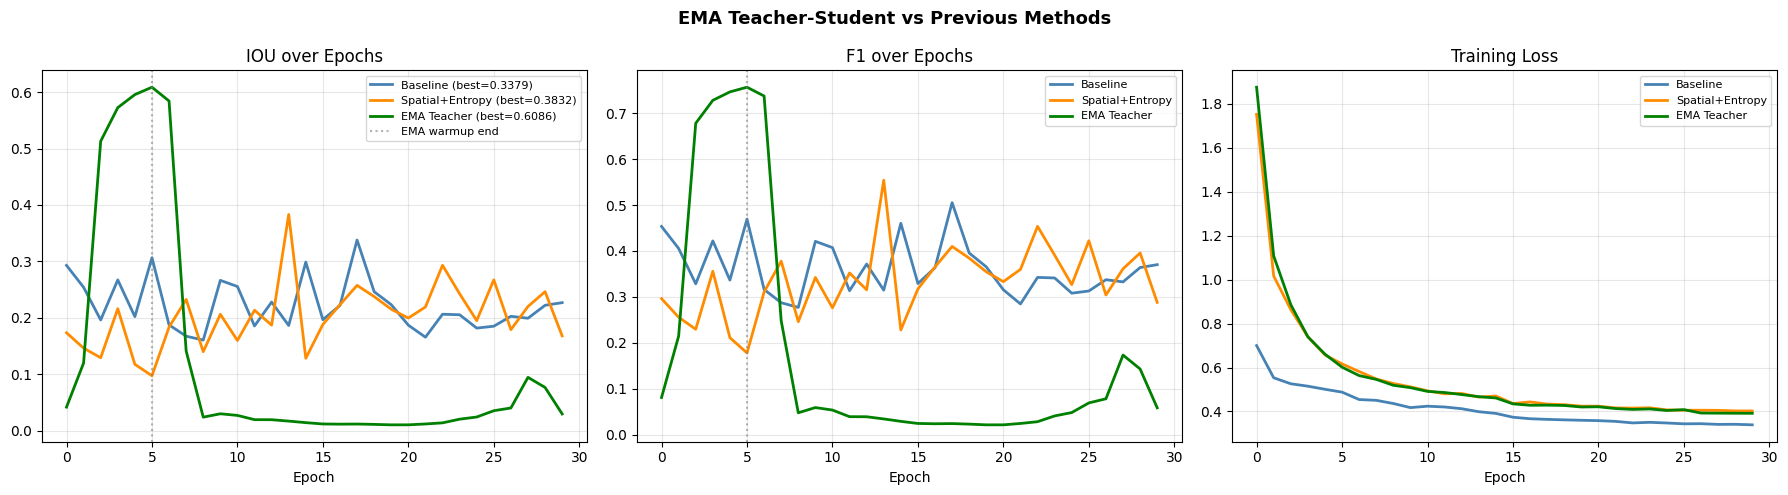


Method                           Best IOU    Best F1
Baseline                           0.3379     0.5052
Spatial+Entropy                    0.3832     0.5541
EMA Teacher-Student                0.6086     0.7567


In [ ]:
# ── CELL 14: Main comparison plot ─────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EMA Teacher-Student vs Previous Methods', fontsize=13, fontweight='bold')

# IOU
axes[0].plot(h_base['iou'],  label=f'Baseline (best={iou_base:.4f})',  color='steelblue', lw=2)
axes[0].plot(h_prev['iou'],  label=f'Spatial+Entropy (best={iou_prev:.4f})', color='darkorange', lw=2)
axes[0].plot(h_ema['iou'],   label=f'EMA Teacher (best={iou_ema:.4f})', color='green', lw=2)
axes[0].axvline(x=5, color='gray', ls=':', alpha=0.6, label='EMA warmup end')
axes[0].set_title('IOU over Epochs'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# F1
axes[1].plot(h_base['f1'],  color='steelblue', lw=2, label='Baseline')
axes[1].plot(h_prev['f1'],  color='darkorange', lw=2, label='Spatial+Entropy')
axes[1].plot(h_ema['f1'],   color='green', lw=2, label='EMA Teacher')
axes[1].axvline(x=5, color='gray', ls=':', alpha=0.6)
axes[1].set_title('F1 over Epochs'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Loss
axes[2].plot(h_base['loss'], color='steelblue', lw=2, label='Baseline')
axes[2].plot(h_prev['loss'], color='darkorange', lw=2, label='Spatial+Entropy')
axes[2].plot(h_ema['loss'],  color='green', lw=2, label='EMA Teacher')
axes[2].set_title('Training Loss'); axes[2].set_xlabel('Epoch'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/results/ema_main_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*55)
print(f'{"Method":<30} {"Best IOU":>10} {"Best F1":>10}')
print('='*55)
print(f'{"Baseline":<30} {iou_base:>10.4f} {f1_base:>10.4f}')
print(f'{"Spatial+Entropy":<30} {iou_prev:>10.4f} {f1_prev:>10.4f}')
print(f'{"EMA Teacher-Student":<30} {iou_ema:>10.4f} {f1_ema:>10.4f}')
print('='*55)


  EMA_ALPHA_0P99
  EMA alpha=0.99 | lambda_ema=0.1 | warmup=3ep
[ShapeNet] train: 5422 samples
[ShapeNet] test: 1356 samples
[ema_alpha_0p99] E00 | loss 1.6248 | Teacher IOU 0.4449 | Student IOU 0.1522 | F1 0.6159  --> Best [warmup]
[ema_alpha_0p99] E01 | loss 0.9505 | Teacher IOU 0.5641 | Student IOU 0.3461 | F1 0.7213  --> Best [warmup]
[ema_alpha_0p99] E02 | loss 0.7829 | Teacher IOU 0.5385 | Student IOU 0.1279 | F1 0.7001 [warmup]
[ema_alpha_0p99] E03 | loss 0.7050 | Teacher IOU 0.5780 | Student IOU 0.3509 | F1 0.7326  --> Best
[ema_alpha_0p99] E04 | loss 0.6311 | Teacher IOU 0.5449 | Student IOU 0.3248 | F1 0.7054
[ema_alpha_0p99] E05 | loss 0.5965 | Teacher IOU 0.0894 | Student IOU 0.0761 | F1 0.1641
[ema_alpha_0p99] E06 | loss 0.5629 | Teacher IOU 0.1014 | Student IOU 0.2338 | F1 0.1842
[ema_alpha_0p99] E07 | loss 0.5385 | Teacher IOU 0.1093 | Student IOU 0.2237 | F1 0.1971
[ema_alpha_0p99] E08 | loss 0.5225 | Teacher IOU 0.0346 | Student IOU 0.1109 | F1 0.0669
[ema_alpha_0p99]

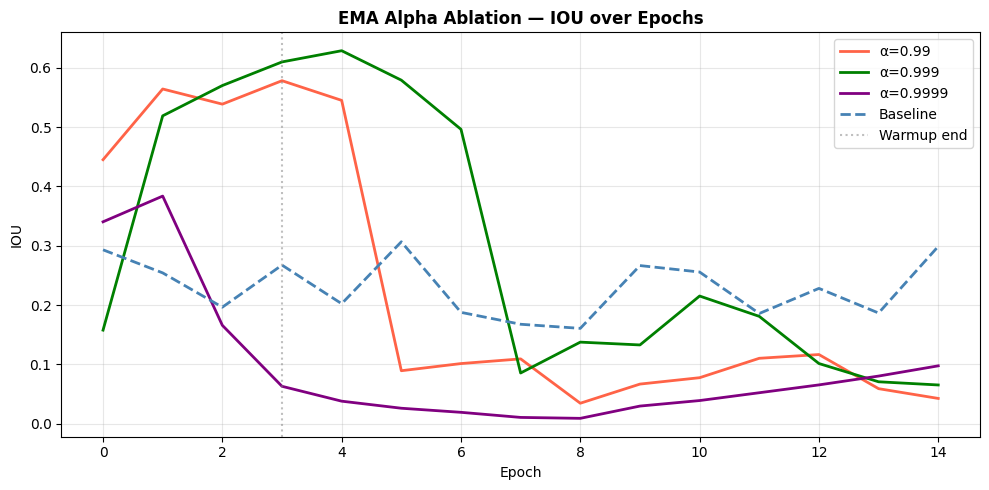


   Alpha    Best IOU     Best F1
    0.99      0.5780      0.7326
   0.999      0.6286      0.7719 ← best
  0.9999      0.3836      0.5545


In [ ]:
# ── CELL 15: Alpha ablation ────────────────────────────────────────────────────
alpha_values = [0.99, 0.999, 0.9999]
alpha_results = {}

for alpha in alpha_values:
    tag = f'ema_alpha_{str(alpha).replace(".","p")}'
    h, iou, f1 = run_ema(
        tag=tag, n_epochs=15,
        lambda_sp=0.01, k_sp=10, lambda_ent=0.0001,
        ema_alpha=alpha, lambda_ema=0.1, ema_warmup_epochs=3
    )
    alpha_results[alpha] = {'iou': iou, 'f1': f1, 'history': h}
    print(f'alpha={alpha}  IOU={iou:.4f}  F1={f1:.4f}')

# Plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tomato', 'green', 'purple']
for alpha, col in zip(alpha_values, colors):
    ax.plot(alpha_results[alpha]['history']['iou'], label=f'α={alpha}', color=col, lw=2)
ax.plot(h_base['iou'][:15], label='Baseline', color='steelblue', lw=2, ls='--')
ax.axvline(x=3, color='gray', ls=':', alpha=0.5, label='Warmup end')
ax.set_title('EMA Alpha Ablation — IOU over Epochs', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('IOU'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/results/ema_alpha_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*45)
print(f'{"Alpha":>8}  {"Best IOU":>10}  {"Best F1":>10}')
print('='*45)
for alpha in alpha_values:
    best = alpha == max(alpha_values, key=lambda a: alpha_results[a]['iou'])
    marker = ' ← best' if best else ''
    print(f'{alpha:>8}  {alpha_results[alpha]["iou"]:>10.4f}  {alpha_results[alpha]["f1"]:>10.4f}{marker}')
print('='*45)

In [ ]:
# ── CELL 16: Lambda_ema ablation ───────────────────────────────────────────────
lema_values = [0.01, 0.1, 0.5]
lema_results = {}

for lema in lema_values:
    tag = f'ema_lam_{str(lema).replace(".","p")}'
    h, iou, f1 = run_ema(
        tag=tag, n_epochs=15,
        lambda_sp=0.01, k_sp=10, lambda_ent=0.0001,
        ema_alpha=0.999, lambda_ema=lema, ema_warmup_epochs=3
    )
    lema_results[lema] = {'iou': iou, 'f1': f1, 'history': h}
    print(f'lambda_ema={lema}  IOU={iou:.4f}  F1={f1:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tomato', 'green', 'purple']
for lema, col in zip(lema_values, colors):
    ax.plot(lema_results[lema]['history']['iou'], label=f'λ_ema={lema}', color=col, lw=2)
ax.plot(h_prev['iou'][:15], label='Spatial+Entropy (no EMA)', color='darkorange', lw=2, ls='--')
ax.axvline(x=3, color='gray', ls=':', alpha=0.5, label='Warmup end')
ax.set_title('EMA λ_ema Ablation — IOU over Epochs', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('IOU'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/results/ema_lambda_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*48)
print(f'{"λ_ema":>8}  {"Best IOU":>10}  {"Best F1":>10}')
print('='*48)
best_lema = max(lema_values, key=lambda l: lema_results[l]['iou'])
for lema in lema_values:
    marker = ' ← best' if lema == best_lema else ''
    print(f'{lema:>8}  {lema_results[lema]["iou"]:>10.4f}  {lema_results[lema]["f1"]:>10.4f}{marker}')
print('='*48)


  EMA_LAM_0P01
  EMA alpha=0.999 | lambda_ema=0.01 | warmup=3ep
[ShapeNet] train: 5422 samples
[ShapeNet] test: 1356 samples
[ema_lam_0p01] E00 | loss 1.9176 | Teacher IOU 0.0128 | Student IOU 0.2792 | F1 0.0253  --> Best [warmup]
[ema_lam_0p01] E01 | loss 0.9914 | Teacher IOU 0.3653 | Student IOU 0.0508 | F1 0.5352  --> Best [warmup]
[ema_lam_0p01] E02 | loss 0.8023 | Teacher IOU 0.5902 | Student IOU 0.1518 | F1 0.7423  --> Best [warmup]
[ema_lam_0p01] E03 | loss 0.7164 | Teacher IOU 0.5390 | Student IOU 0.0355 | F1 0.7004
[ema_lam_0p01] E04 | loss 0.6411 | Teacher IOU 0.4526 | Student IOU 0.1921 | F1 0.6232
[ema_lam_0p01] E05 | loss 0.6011 | Teacher IOU 0.5071 | Student IOU 0.2134 | F1 0.6729
[ema_lam_0p01] E06 | loss 0.5587 | Teacher IOU 0.4817 | Student IOU 0.1733 | F1 0.6502
[ema_lam_0p01] E07 | loss 0.5341 | Teacher IOU 0.4391 | Student IOU 0.4048 | F1 0.6103
[ema_lam_0p01] E08 | loss 0.5175 | Teacher IOU 0.5039 | Student IOU 0.2531 | F1 0.6702
[ema_lam_0p01] E09 | loss 0.5074 |

In [ ]:
# ── CELL 17: Complete final summary ───────────────────────────────────────────
print('\n' + '='*65)
print('  COMPLETE EMA EXPERIMENT RESULTS')
print('='*65)

# Historical saved results
saved_baseline = 0.4031
saved_entropy  = 0.4885

print(f'\n  Historical best (saved from previous sessions):')
print(f'    Baseline                   IOU={saved_baseline:.4f}')
print(f'    Spatial+Entropy (15 ep)    IOU={saved_entropy:.4f}  ← previous best')

print(f'\n  This session (30 epochs, fresh training):')
print(f'    Baseline                   IOU={iou_base:.4f}')
print(f'    Spatial+Entropy            IOU={iou_prev:.4f}')
print(f'    EMA Teacher-Student        IOU={iou_ema:.4f}')

delta_ema_vs_prev = iou_ema - iou_prev
delta_ema_vs_base = iou_ema - iou_base
print(f'\n  EMA vs Spatial+Entropy:  {delta_ema_vs_prev:+.4f}')
print(f'  EMA vs Baseline:         {delta_ema_vs_base:+.4f}')

print(f'\n  Alpha ablation (λ_ema=0.1, 15 epochs):')
for alpha in alpha_values:
    print(f'    α={alpha}  IOU={alpha_results[alpha]["iou"]:.4f}')

print(f'\n  Lambda_ema ablation (α=0.999, 15 epochs):')
for lema in lema_values:
    print(f'    λ_ema={lema}  IOU={lema_results[lema]["iou"]:.4f}')

print('\n' + '='*65)

# Key observation about stability
iou_variance_prev = float(np.var(h_prev['iou']))
iou_variance_ema  = float(np.var(h_ema['iou']))
print(f'\n  IOU variance (epoch-to-epoch):')
print(f'    Spatial+Entropy:    {iou_variance_prev:.6f}')
print(f'    EMA Teacher:        {iou_variance_ema:.6f}')
if iou_variance_ema < iou_variance_prev:
    reduction = (1 - iou_variance_ema/iou_variance_prev)*100
    print(f'    → EMA reduced variance by {reduction:.1f}% (more stable training)')
else:
    print(f'    → EMA did not reduce variance in this run')

In [ ]:
# ── CELL 18: Save to Google Drive ─────────────────────────────────────────────
import shutil
dest = '/content/drive/MyDrive/BTP_coseg_EMA'
os.makedirs(dest, exist_ok=True)
shutil.copytree('/content/results', dest, dirs_exist_ok=True)
print('Saved to Drive:', dest)
for f in os.listdir('/content/results'):
    if f.endswith('.png'): print(' ', f)